# Module 2 — Part 3: Expected Delay Duration Regression (`delay_duration_days`)

**Objective:** For delayed shipments, estimate how many days the delay will be, using the processed features from Part 1.

**Input files (from Part 1):**
- `X_train_processed.csv`, `X_test_processed.csv` — encoded feature matrices (same pipeline as Part 2)
- `delay_y_train.csv`, `delay_y_test.csv` — target: `delay_duration_days` (0–4)

**Models compared:** XGBoost Regressor vs LightGBM Regressor


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
import joblib
import pickle

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
RANDOM_STATE = 42


## 2. Load Processed Data

In [2]:
X_train_p = pd.read_csv('X_train_processed.csv')
X_test_p = pd.read_csv('X_test_processed.csv')
y_train = pd.read_csv('delay_y_train.csv')['delay_duration_days']
y_test = pd.read_csv('delay_y_test.csv')['delay_duration_days']

print(f"X_train_p: {X_train_p.shape}, X_test_p: {X_test_p.shape}")


X_train_p: (144415, 77), X_test_p: (36104, 77)


## 3. Baseline Model — XGBoost Regressor

In [3]:
xgb_reg = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_reg.fit(X_train_p, y_train)
xgb_pred = xgb_reg.predict(X_test_p)

print("XGBoost Regressor Results")
print("-" * 40)
print(f"MAE:  {mean_absolute_error(y_test, xgb_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_pred)):.4f}")
print(f"R2:   {r2_score(y_test, xgb_pred):.4f}")


XGBoost Regressor Results
----------------------------------------
MAE:  0.6615
RMSE: 0.8348
R2:   0.3465


## 4. Comparison Model — LightGBM Regressor

In [4]:
lgb_reg = lgb.LGBMRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgb_reg.fit(X_train_p, y_train)
lgb_pred = lgb_reg.predict(X_test_p)

print("LightGBM Regressor Results")
print("-" * 40)
print(f"MAE:  {mean_absolute_error(y_test, lgb_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lgb_pred)):.4f}")
print(f"R2:   {r2_score(y_test, lgb_pred):.4f}")


LightGBM Regressor Results
----------------------------------------
MAE:  0.6713
RMSE: 0.8481
R2:   0.3254


## 5. Model Comparison Summary

In [5]:
comparison = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'MAE': [mean_absolute_error(y_test, xgb_pred), mean_absolute_error(y_test, lgb_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, xgb_pred)), np.sqrt(mean_squared_error(y_test, lgb_pred))],
    'R2': [r2_score(y_test, xgb_pred), r2_score(y_test, lgb_pred)],
}).set_index('Model').round(4)
comparison


,MAE,RMSE,R2
Model,,,
XGBoost,0.6615,0.8348,0.3465
LightGBM,0.6713,0.8481,0.3254


In [6]:
best_model_name = comparison['MAE'].idxmin()
best_model = xgb_reg if best_model_name == 'XGBoost' else lgb_reg
best_pred = xgb_pred if best_model_name == 'XGBoost' else lgb_pred
print(f"Best model (lowest MAE): {best_model_name}")


Best model (lowest MAE): XGBoost


## 6. Predicted vs Actual, Feature Importance & Cross-Validation

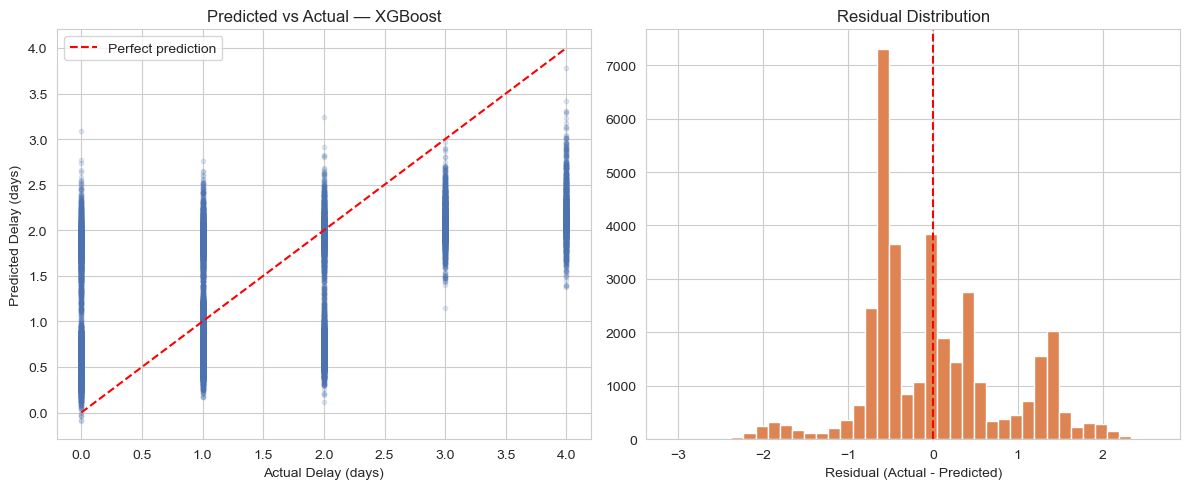

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, best_pred, alpha=0.15, s=10, color='#4C72B0')
axes[0].plot([0, y_test.max()], [0, y_test.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual Delay (days)'); axes[0].set_ylabel('Predicted Delay (days)')
axes[0].set_title(f'Predicted vs Actual — {best_model_name}')
axes[0].legend()

residuals = y_test - best_pred
axes[1].hist(residuals, bins=40, color='#DD8452', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()


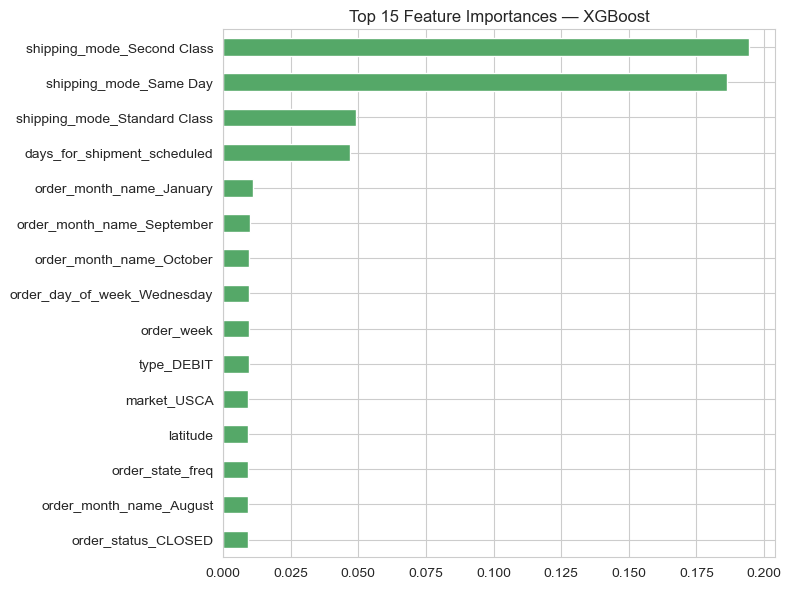

In [8]:
importances = pd.Series(best_model.feature_importances_, index=X_train_p.columns)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_features.sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_title(f'Top 15 Feature Importances — {best_model_name}')
plt.tight_layout()
plt.show()


In [9]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_model = xgb_reg if best_model_name == 'XGBoost' else lgb_reg
cv_scores = -cross_val_score(cv_model, X_train_p, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
print(f"CV MAE scores: {np.round(cv_scores, 4)}")
print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")


CV MAE scores: [0.6678 0.674  0.6689 0.6683 0.6677]
Mean: 0.6693  |  Std: 0.0023


## 7. Save Model

In [10]:
with open('shared_preprocessing.pkl', 'rb') as f:
    shared_artifacts = pickle.load(f)

if best_model_name == 'XGBoost':
    best_model.save_model('delay_duration_xgb.json')
else:
    joblib.dump(best_model, 'delay_duration_lgb.pkl')

regression_artifacts = dict(shared_artifacts)
regression_artifacts['best_model_name'] = best_model_name
with open('regression_preprocessing.pkl', 'wb') as f:
    pickle.dump(regression_artifacts, f)

print(f"Saved model ({best_model_name}) and preprocessing artifacts.")


Saved model (XGBoost) and preprocessing artifacts.


## Summary

- Compared XGBoost and LightGBM regressors for predicting `delay_duration_days`
- Selected the best model by MAE, validated with 5-fold cross-validation
- Saved the model and preprocessing pipeline for Module 4 handoff

**Next: Part 4 — Combine both models to generate the Module 3 handoff file.**
